# **Steps:**

*	Preprocess + EDA + Feature Selection
*	Extract input and output cols
*	Scale the values
*	Train test split
*	Train the model
*	Evaluate the model/model selection
*	Deploy the model

In [5]:
import numpy as np
import pandas as pd

In [6]:
df = pd.read_csv('/content/placement.csv')

In [7]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [9]:
df.shape

(100, 4)

In [10]:
df = df.iloc[:,1:] #Preprocessing

In [12]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [19]:
import matplotlib.pyplot as plt

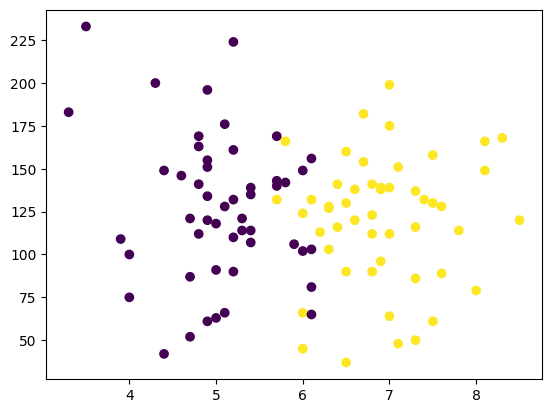

In [21]:
plt.scatter(df['cgpa'],df['iq'], c=df['placement']) # Exploratory Data Analysis

In [26]:
X = df.iloc[:,0:2] # Extact Input aka Independent Var

In [27]:
y = df.iloc[:,-1] # Extact Output aka dependent Var

In [28]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [29]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [35]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.1) #Train Test Input

In [36]:
X_train # X Training Data

,cgpa,iq
5,7.1,48.0
29,7.0,112.0
62,6.0,102.0
41,5.4,114.0
46,5.3,114.0
...,...,...
65,8.1,166.0
89,4.9,151.0
6,5.7,143.0
69,8.5,120.0


In [37]:
X_test # X Testing Data

,cgpa,iq
77,7.3,50.0
40,4.9,134.0
3,7.4,132.0
43,6.8,141.0
78,6.1,81.0
11,6.9,138.0
16,5.2,224.0
85,5.8,166.0
22,4.9,120.0
12,5.4,139.0


In [38]:
y_train # y Training Data

,placement
5,1
29,1
62,0
41,0
46,0
...,...
65,1
89,0
6,0
69,1


In [39]:
y_test # y Testing Data

,placement
77,1
40,0
3,1
43,1
78,0
11,1
16,0
85,1
22,0
12,0


In [51]:
from sklearn.preprocessing import StandardScaler # Scale the values

In [52]:
scaler = StandardScaler()

In [53]:
X_train = scaler.fit_transform(X_train) # Scaling the X Train values

In [54]:
X_train

array([[ 0.96444784, -1.90608715],
       [ 0.87816523, -0.27059453],
       [ 0.01533913, -0.52614025],
       [-0.50235653, -0.21948538],
       [-0.58863914, -0.21948538],
       [-0.76120436, -1.44610485],
       [ 0.87816523,  0.41937892],
       [-0.58863914, -0.04060338],
       [-0.84748697, -1.52276857],
       [ 0.18790435, -0.24503995],
       [-0.67492175,  0.98157951],
       [-1.71031306, -0.57724939],
       [ 0.6193174 ,  1.51822553],
       [-0.84748697, -0.80724054],
       [ 0.44675218, -2.18718744],
       [-0.50235653,  0.31716064],
       [-2.14172611,  2.82150872],
       [ 0.01533913,  0.67492465],
       [ 0.01533913,  0.03606034],
       [ 0.27418696,  0.11272406],
       [-1.79659567, -0.34725824],
       [-1.10633479, -1.80386886],
       [ 0.79188262, -0.67946768],
       [ 1.30957827, -1.57387771],
       [ 0.79188262,  0.41937892],
       [ 0.36046957, -0.16837624],
       [-1.02005218,  1.03268866],
       [ 0.87816523,  1.95265326],
       [ 0.10162174,

In [55]:
X_test = scaler.transform(X_test) # Scaling the X Test values

In [46]:
X_test

array([[ 1.33247733, -1.88003213],
       [-1.26747844,  0.0341824 ],
       [ 1.44080882, -0.01139413],
       [ 0.79081988,  0.19370028],
       [ 0.03249945, -1.17359581],
       [ 0.89915137,  0.12533548],
       [-0.94248396,  2.08512654],
       [-0.29249502,  0.76340699],
       [-1.26747844, -0.28485335],
       [-0.72582098,  0.14812374]])

In [56]:
from sklearn.linear_model import LogisticRegression # Logistic Regression Model

In [57]:
clf = LogisticRegression()

In [59]:
clf.fit(X_train, y_train) # Training the Model

LogisticRegression()

In [65]:
clf.predict(X_test) # Testing the Model

array([1, 0, 1, 1, 1, 1, 0, 0, 0, 0])

In [67]:
y_pred = clf.predict(X_test) # Saving predicted Values in y_pred

In [68]:
y_test # Actual Values

,placement
77,1
40,0
3,1
43,1
78,0
11,1
16,0
85,1
22,0
12,0


In [70]:
from sklearn.metrics import accuracy_score # Accuracy Score

In [71]:
accuracy_score(y_test, y_pred) # Accuracy Score in percentage

0.8

In [72]:
from mlxtend.plotting import plot_decision_regions # Decision Region Plot

<Axes: >

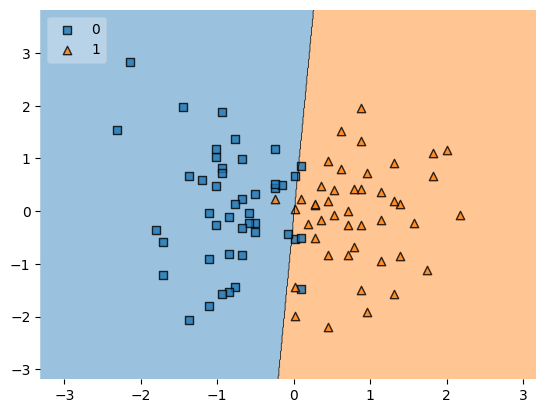

In [74]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [78]:
import pickle

In [79]:
pickle.dump(clf, open('model.pkl', 'wb'))